In [35]:
#@title Package Installations
#!pip install lime

In [36]:
#@title Imports
from google.colab import drive
import json
import inspect
import random
import xgboost as xgb
import matplotlib.pyplot as plt
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import lime
import lime.lime_tabular
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [37]:
#@title Constants
ROOT_DIR = '/content/drive'
BACHELOR_DIR = ROOT_DIR + '/MyDrive/Bachelor'
DATASET_DIR = BACHELOR_DIR + '/datasets/dataset.json'

FEATURE_NAMES = [
     'url_length', 'domain_length', 'is_domain_ip', 'top_level_domain_length',
     'number_of_sub_domains', 'number_of_digits_in_url', 'digit_ratio_in_url',
     'number_of_special_characters_in_url', 'special_character_ratio_in_url',
     'is_https', 'is_responsive', 'number_of_url_redirects', 'number_of_self_redirects',
     'url_similarity_index', 'lines_of_code', 'largest_line_length', 'has_title',
     'has_favicon', 'has_description', 'number_of_pop_ups', 'has_password_field',
     'has_copyright_info', 'number_of_images', 'has_payment_functionality',
     'has_social_network'
]

In [38]:
#@title Classes
class DatasetOptions:
  def __init__(self,
    number_of_rows: int,
    percentage_of_training_data: float,
    percentage_of_validation_data: float,
    percentage_of_testing_data: float) -> None:

    self.number_of_rows = number_of_rows
    self.percentage_of_training_data = percentage_of_training_data
    self.percentage_of_validation_data = percentage_of_validation_data
    self.percentage_of_testing_data = percentage_of_testing_data
  def __str__(self) -> str:
    return (
      f"DatasetOptions(\n"
      f"number_of_rows = {self.number_of_rows}\n"
      f"percentage_of_training_data = {self.percentage_of_training_data}\n"
      f"percentage_of_validation_data = {self.percentage_of_validation_data}\n"
      f"percentage_of_testing_data = {self.percentage_of_testing_data}\n"
      f")")

class Dataset:
  def __init__(self,
    url_length: int,
    domain_length: int,
    is_domain_ip: bool,
    top_level_domain_length: int,
    number_of_sub_domains: int,
    number_of_digits_in_url: int,
    digit_ratio_in_url: float,
    number_of_special_characters_in_url: int,
    special_character_ratio_in_url: float,
    is_https: bool,
    is_responsive: bool,
    number_of_url_redirects: int,
    number_of_self_redirects: int,
    url_similarity_index: float,
    lines_of_code: int,
    largest_line_length: int,
    has_title: bool,
    has_favicon: bool,
    has_description: bool,
    number_of_pop_ups: int,
    has_password_field: bool,
    has_copyright_info: bool,
    number_of_images: int,
    has_payment_functionality: bool,
    has_social_network: bool,
    label: bool) -> None:

    self.url_length = url_length
    self.domain_length = domain_length
    self.is_domain_ip = is_domain_ip
    self.top_level_domain_length = top_level_domain_length
    self.number_of_sub_domains = number_of_sub_domains
    self.number_of_digits_in_url = number_of_digits_in_url
    self.digit_ratio_in_url = digit_ratio_in_url
    self.number_of_special_characters_in_url = number_of_special_characters_in_url
    self.special_character_ratio_in_url = special_character_ratio_in_url
    self.is_https = is_https
    self.is_responsive = is_responsive
    self.number_of_url_redirects = number_of_url_redirects
    self.number_of_self_redirects = number_of_self_redirects
    self.url_similarity_index = url_similarity_index
    self.lines_of_code = lines_of_code
    self.largest_line_length = largest_line_length
    self.has_title = has_title
    self.has_favicon = has_favicon
    self.has_description = has_description
    self.number_of_pop_ups = number_of_pop_ups
    self.has_password_field = has_password_field
    self.has_copyright_info = has_copyright_info
    self.number_of_images = number_of_images
    self.has_payment_functionality = has_payment_functionality
    self.has_social_network = has_social_network
    self.label = label

  def __str__(self) -> str:
    return (
      f"Dataset(\n"
      f"  url_length = {self.url_length}\n"
      f"  domain_length = {self.domain_length}\n"
      f"  is_domain_ip = {self.is_domain_ip}\n"
      f"  top_level_domain_length = {self.top_level_domain_length}\n"
      f"  number_of_sub_domains = {self.number_of_sub_domains}\n"
      f"  number_of_digits_in_url = {self.number_of_digits_in_url}\n"
      f"  digit_ratio_in_url = {self.digit_ratio_in_url}\n"
      f"  number_of_special_characters_in_url = {self.number_of_special_characters_in_url}\n"
      f"  special_character_ratio_in_url = {self.special_character_ratio_in_url}\n"
      f"  is_https = {self.is_https}\n"
      f"  is_responsive = {self.is_responsive}\n"
      f"  number_of_url_redirects = {self.number_of_url_redirects}\n"
      f"  number_of_self_redirects = {self.number_of_self_redirects}\n"
      f"  url_similarity_index = {self.url_similarity_index}\n"
      f"  lines_of_code = {self.lines_of_code}\n"
      f"  largest_line_length = {self.largest_line_length}\n"
      f"  has_title = {self.has_title}\n"
      f"  has_favicon = {self.has_favicon}\n"
      f"  has_description = {self.has_description}\n"
      f"  number_of_pop_ups = {self.number_of_pop_ups}\n"
      f"  has_password_field = {self.has_password_field}\n"
      f"  has_copyright_info = {self.has_copyright_info}\n"
      f"  number_of_images = {self.number_of_images}\n"
      f"  has_payment_functionality = {self.has_payment_functionality}\n"
      f"  has_social_network = {self.has_social_network}\n"
      f"  label = {self.label}\n"
      f")")

In [39]:
#@title Mount Google Drive
drive.mount(ROOT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
#@title Data Preparation
def prepare_datasets(dataset_dir: str, dataset_options: DatasetOptions) -> tuple[list[Dataset], list[Dataset], list[Dataset]]:
  try:
    with open(dataset_dir, mode = "r") as dataset_file:
      print(f"Reading data from {dataset_dir} ...")
      json_dataset = json.load(dataset_file)
      dataset: list[Dataset] = []
      for json_object in json_dataset:
        row: Dataset = Dataset(url_length = json_object["URLLength"],
                              domain_length = json_object["DomainLenght"],
                              is_domain_ip = json_object["IsDomainIP"],
                              top_level_domain_length = json_object["TopLevelDomainLength"],
                              number_of_sub_domains = json_object["NumberOfSubDomains"],
                              number_of_digits_in_url = json_object["NumberOfDigitsInURL"],
                              digit_ratio_in_url = json_object["DigitRationInURL"],
                              number_of_special_characters_in_url = json_object["NumberOfSpecialCharactersInURL"],
                              special_character_ratio_in_url = json_object["SpecialCharactersRatioInURL"],
                              is_https = json_object["IsHTTPS"],
                              is_responsive = json_object["IsResponsive"],
                              number_of_url_redirects = json_object["NumberOfURLRedirects"],
                              number_of_self_redirects = json_object["NumberOfSelfRedirects"],
                              url_similarity_index = json_object["URLSimilarityIndex"],
                              lines_of_code = json_object["LinesOfCode"],
                              largest_line_length = json_object["LargestLineLenght"],
                              has_title = json_object["HasTitle"],
                              has_favicon = json_object["HasFavicon"],
                              has_description = json_object["HasDescription"],
                              number_of_pop_ups = json_object["NumberOfPopUps"],
                              has_password_field = json_object["HasPasswordField"],
                              has_copyright_info = json_object["HasCopyrightInfo"],
                              number_of_images = json_object["NumberOfImages"],
                              has_payment_functionality = json_object["HasPaymentFunctionality"],
                              has_social_network = json_object["HasSocialNetwork"],
                              label = bool(json_object["Label"]))
        dataset.append(row)

      random.shuffle(dataset)

      total_rows: int = len(dataset)
      if (dataset_options.number_of_rows > total_rows):
        print(f"Number of rows selected {dataset_options.number_of_rows} are greater than the total count of rows {total_rows}. Model will proceed with {total_rows}")
        dataset_options.number_of_rows = total_rows

      selectedDataset: list[Dataset] = []
      for i in range(dataset_options.number_of_rows):
        selectedDataset.append(dataset[i])

      training_dataset: list[Dataset] = []
      validation_dataset: list[Dataset] = []
      testing_dataset: list[Dataset] = []
      training_dataset, validation_dataset, testing_dataset = split_dataset(dataset_options = dataset_options, dataset = selectedDataset)

      print_dataset_information(dataset = dataset, dataset_options = dataset_options,
                                training_dataset = training_dataset, validation_dataset = validation_dataset, testing_dataset = testing_dataset)

    return training_dataset, validation_dataset, testing_dataset

  except Exception as e:
    function_name = inspect.currentframe().f_code.co_name
    print(f"Unexpected error in {function_name}: {e}")

def print_dataset_information(dataset: list[Dataset], dataset_options: DatasetOptions,
                              training_dataset: list[Dataset], validation_dataset: list[Dataset], testing_dataset: list[Dataset]) -> None:
  try:
      print_one_dataset_information(dataset = dataset, text_type = "TOTAL")

      print(f"{dataset_options.number_of_rows} number of rows were selected")

      print_one_dataset_information(dataset = training_dataset, text_type = "TRAINING")
      print_one_dataset_information(dataset = validation_dataset, text_type = "VALIDATION")
      print_one_dataset_information(dataset = testing_dataset, text_type = "TESTING")

  except Exception as e:
    function_name = inspect.currentframe().f_code.co_name
    print(f"Unexpected error in {function_name}: {e}")

def print_one_dataset_information(dataset: list[Dataset], text_type: str) -> None:
  total_rows: int = len(dataset)
  print(f"{total_rows} rows in {text_type} dataset")

  phishing_url_count: int = 0
  legitimate_url_count: int = 0

  for row in dataset:
    if (row.label == 1):
      phishing_url_count += 1
    else:
      legitimate_url_count += 1

  phishing_url_percentage: float = (phishing_url_count / total_rows) * 100
  legitimate_url_percentage: float = (legitimate_url_count / total_rows) * 100

  print(f"  {phishing_url_count} phishing rows were found ({phishing_url_percentage:.2f}%)")
  print(f"  {legitimate_url_count} legitimate rows were found ({legitimate_url_percentage:.2f}%)")

def split_dataset(dataset_options: DatasetOptions, dataset: list[Dataset]) -> tuple[list[Dataset], list[Dataset], list[Dataset]]:
  total_rows = len(dataset)

  training_end: int = int(dataset_options.number_of_rows * dataset_options.percentage_of_training_data)
  validation_end: int = training_end + int(dataset_options.number_of_rows * dataset_options.percentage_of_validation_data)

  training_dataset: list[Dataset] = dataset[:training_end]
  validation_dataset: list[Dataset] = dataset[training_end:validation_end]
  testing_dataset: list[Dataset] = dataset[validation_end:]

  return training_dataset, validation_dataset, testing_dataset

In [41]:
#@title Dataset to DMatrix conversion

def dataset_to_feature_vectors(dataset: list[Dataset]):
  features = []
  labels = []

  for row in dataset:
    row_feature = [
        row.url_length,
        row.domain_length,
        int(row.is_domain_ip),
        row.top_level_domain_length,
        row.number_of_sub_domains,
        row.number_of_digits_in_url,
        row.digit_ratio_in_url,
        row.number_of_special_characters_in_url,
        row.special_character_ratio_in_url,
        int(row.is_https),
        int(row.is_responsive),
        row.number_of_url_redirects,
        row.number_of_self_redirects,
        row.url_similarity_index,
        row.lines_of_code,
        row.largest_line_length,
        int(row.has_title),
        int(row.has_favicon),
        int(row.has_description),
        row.number_of_pop_ups,
        int(row.has_password_field),
        int(row.has_copyright_info),
        int(row.number_of_images),
        int(row.has_payment_functionality),
        int(row.has_social_network)
    ]

    features.append(row_feature)
    labels.append(int(row.label))

  return features, labels

def feature_vectors_to_DMatrix(features, labels):
  return xgb.DMatrix(data = features, label = labels)

def dataset_to_DMatrix(dataset: list[Dataset]):
  features, labels = dataset_to_feature_vectors(dataset = dataset)
  DMatrix = feature_vectors_to_DMatrix(features = features, labels = labels)
  return DMatrix

In [42]:
#@title Parameter Configurations
parameters1 = {
  'max_depth': 6,
  'eta': 0.1,
  'objective': 'binary:logistic',
  'tree_method': 'hist',
  'device': 'cuda',
  'eval_metric': ['logloss', 'error']
}

In [43]:
#@title XGBoost Models
def xgboost_model1(parameters, training_DMatrix, validation_DMatrix):
  print(f"Running model with parameters: {parameters}")

  evals_result = {}

  model = xgb.train(
      params = parameters,
      dtrain = training_DMatrix,
      num_boost_round = 100,
      evals = [(training_DMatrix, 'Train'), (validation_DMatrix, 'Validation')],
      verbose_eval = 10,
      evals_result = evals_result
  )

  return model, evals_result

def test_xgboost_model(model, testing_DMatrix):
  probabilities = model.predict(testing_DMatrix)
  predictions = [1 if probability > 0.5 else 0 for probability in probabilities]

  return predictions

In [44]:
#@title Testing Functions (delete these later)

In [45]:
#@title Graph Functions
# The plot_data method was generated by Gemini
def plot_data(results):
  epochs = len(results['Train']['logloss'])
  x_axis = range(0, epochs)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

  # Plot 1: Log Loss (Logarithmic Error)
  ax1.plot(x_axis, results['Train']['logloss'], label='Train')
  ax1.plot(x_axis, results['Validation']['logloss'], label='Validation')
  ax1.set_title('XGBoost Log Loss')
  ax1.set_ylabel('Log Loss')
  ax1.set_xlabel('Boosting Round')
  ax1.legend()

  # Plot 2: Accuracy (1 - Error)
  # We convert 'error' to 'accuracy' for better readability
  train_acc = [1 - x for x in results['Train']['error']]
  val_acc = [1 - x for x in results['Validation']['error']]

  ax2.plot(x_axis, train_acc, label='Train')
  ax2.plot(x_axis, val_acc, label='Validation')
  ax2.set_title('XGBoost Accuracy')
  ax2.set_ylabel('Accuracy')
  ax2.set_xlabel('Boosting Round')
  ax2.legend()

  plt.tight_layout()
  plt.show()

# The plot_confusion_matrix method was generated by Gemini
def plot_confusion_matrix(labels, predictions):
  matrix = confusion_matrix(labels, predictions)
  plt.figure(figsize=(6, 5))
  sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix - Phishing URL Detection')
  plt.show()

In [46]:
#@title Model's performance metrics
# The calculate_and_print_performance_metrics method was generated by Gemini
def calculate_and_print_performance_metrics(labels, predictions):
  accuracy = accuracy_score(labels, predictions)
  precision = precision_score(labels, predictions)
  recall = recall_score(labels, predictions)
  f1 = f1_score(labels, predictions)

  print(f"--- Test Dataset Results ---")
  print(f"Accuracy:  {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall:    {recall:.4f}")
  print(f"F1 Score:  {f1:.4f}")
  print("\nDetailed Classification Report:")
  print(classification_report(labels, predictions, target_names=['Legitimate', 'Phishing']))

In [47]:
#@title XGBoost Built-in Feature Importance (Gain)
def xgboost_gain(model, number_of_features):
  model.feature_names = FEATURE_NAMES
  plt.figure(figsize = (10, 8))
  xgb.plot_importance(model, max_num_features = number_of_features, importance_type = 'gain', xlabel = 'Gain (Feature Importance)')
  plt.title('XGBoost Global Feature Importance (Gain)')
  plt.tight_layout()
  plt.show()

In [48]:
#@title LIME Analysis (Global Feature Importance)
def lime_analysis(model, training_dataset, testing_dataset, random_state, instances):
  training_features, _ = dataset_to_feature_vectors(training_dataset)
  testing_features, testing_labels = dataset_to_feature_vectors(testing_dataset)
  training_features_np = np.array(training_features)
  testing_features_np = np.array(testing_features)

  explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = training_features_np,
    feature_names = FEATURE_NAMES,
    class_names = ['Legitimate', 'Phishing'],
    mode = 'classification',
    random_state = random_state
  )

  print(f"\n--- Running LIME Aggregation on {instances} instances... ---")
  all_feature_weights = defaultdict(float)

  for i in tqdm(range(instances), desc="Explaining instances"):
    exp_global = explainer.explain_instance(
      testing_features_np[i],
      predict_probability_for_lime(model = model),
      num_features=len(FEATURE_NAMES)
    )

    for feature_idx, weight in exp_global.as_map()[1]:
      feature_name = FEATURE_NAMES[feature_idx]
      all_feature_weights[feature_name] += weight

  sorted_features = sorted(all_feature_weights.items(), key=lambda x: x[1], reverse=True)
  top_phishing_features = sorted_features[:10]  # Top 10 pushing to Phishing
  top_legitimate_features = sorted_features[-10:] # Top 10 pushing to Legitimate

  phishing_names, phishing_weights = zip(*top_phishing_features)
  plt.figure(figsize=(10, 5))
  plt.barh(phishing_names[::-1], phishing_weights[::-1], color='salmon')
  plt.xlabel('Aggregated Impact Score')
  plt.title('Features driving model towards PHISHING')
  plt.tight_layout()
  plt.show()

  legit_names, legit_weights = zip(*top_legitimate_features)
  plt.figure(figsize=(10, 5))
  plt.barh(legit_names[::-1], [abs(w) for w in legit_weights][::-1], color='lightgreen')
  plt.xlabel('Aggregated Impact Score')
  plt.title('Features driving model towards LEGITIMATE')
  plt.tight_layout()
  plt.show()

def predict_probability_for_lime(model):
  def predict(data):
    dmatrix = xgb.DMatrix(data, feature_names=FEATURE_NAMES)
    probs_phishing = model.predict(dmatrix)
    probs_legitimate = 1.0 - probs_phishing
    return np.vstack((probs_legitimate, probs_phishing)).T
  return predict

DatasetOptions(
number_of_rows = 235795
percentage_of_training_data = 0.8
percentage_of_validation_data = 0.1
percentage_of_testing_data = 0.1
)
Reading data from /content/drive/MyDrive/Bachelor/datasets/dataset.json ...
235795 rows in TOTAL dataset
  100945 phishing rows were found (42.81%)
  134850 legitimate rows were found (57.19%)
235795 number of rows were selected
188636 rows in TRAINING dataset
  80722 phishing rows were found (42.79%)
  107914 legitimate rows were found (57.21%)
23579 rows in VALIDATION dataset
  10053 phishing rows were found (42.64%)
  13526 legitimate rows were found (57.36%)
23580 rows in TESTING dataset
  10170 phishing rows were found (43.13%)
  13410 legitimate rows were found (56.87%)
Running model with parameters: {'max_depth': 6, 'eta': 0.1, 'objective': 'binary:logistic', 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': ['logloss', 'error']}
[0]	Train-logloss:0.58778	Train-error:0.42792	Validation-logloss:0.58743	Validation-error:0.42635
[10]

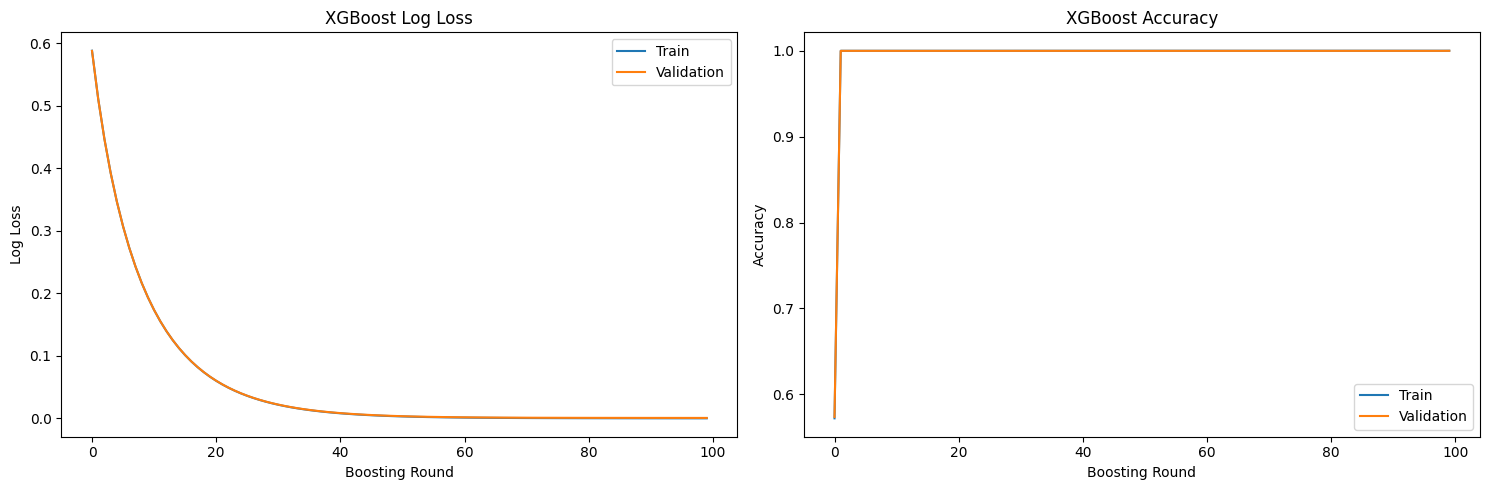

--- Test Dataset Results ---
Accuracy:  0.9999
Precision: 1.0000
Recall:    0.9997
F1 Score:  0.9999

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     13410
    Phishing       1.00      1.00      1.00     10170

    accuracy                           1.00     23580
   macro avg       1.00      1.00      1.00     23580
weighted avg       1.00      1.00      1.00     23580



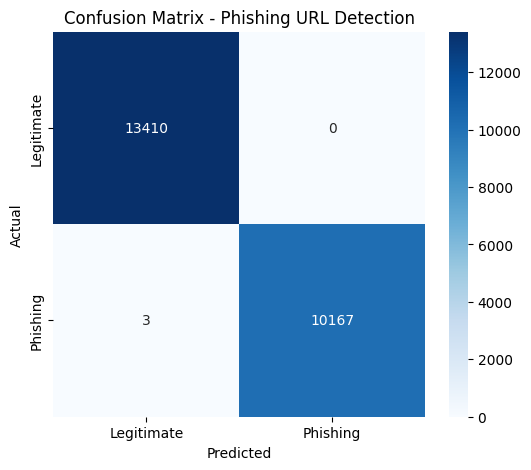

<Figure size 1000x800 with 0 Axes>

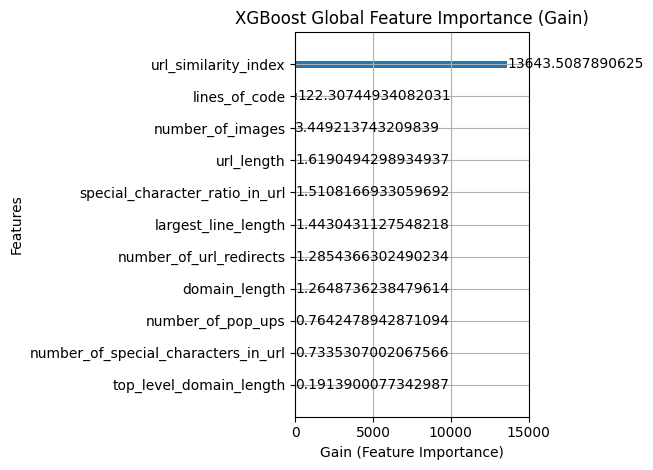


--- Running LIME Aggregation on 1000 instances... ---


Explaining instances:   0%|          | 0/1000 [00:00<?, ?it/s]

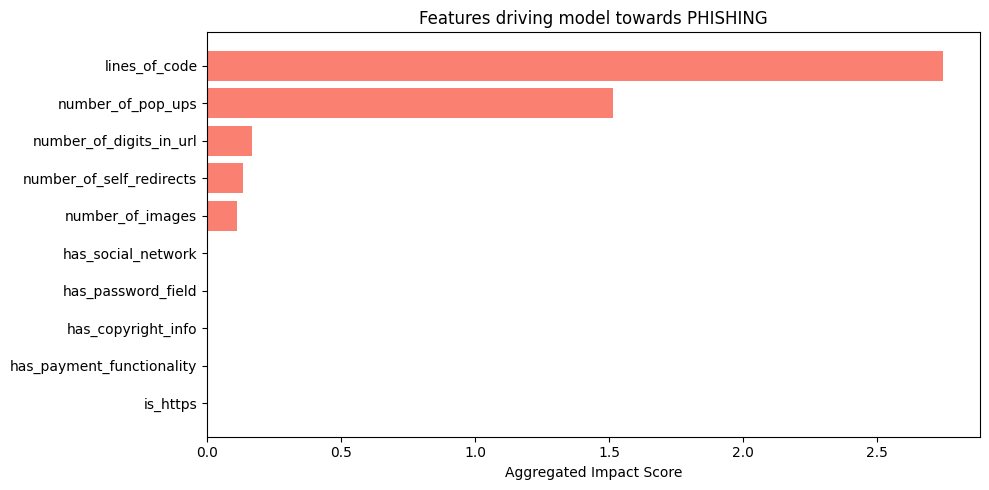

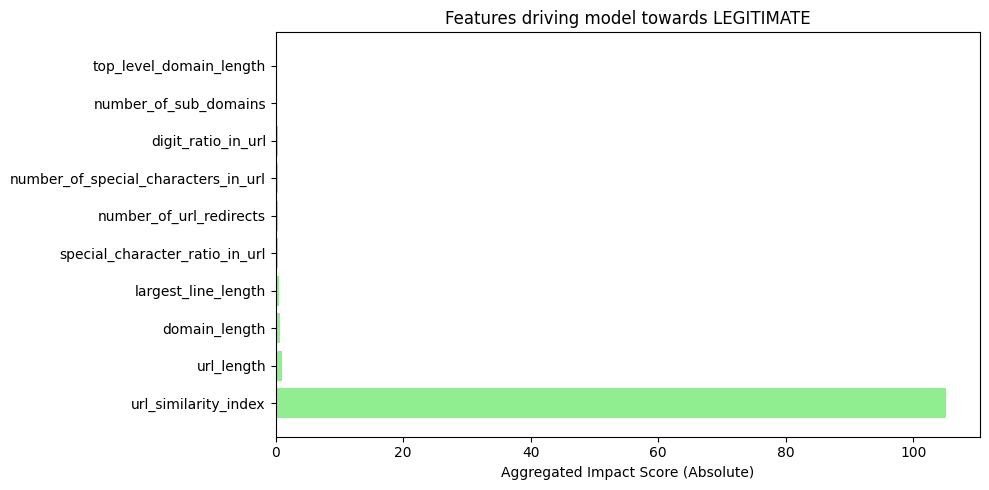

In [49]:
#@title Main
dataset_options: DatasetOptions = DatasetOptions(number_of_rows = 235795,
                                                 percentage_of_training_data = 0.8,
                                                 percentage_of_validation_data = 0.1,
                                                 percentage_of_testing_data = 0.1)

print(dataset_options)

training_dataset: list[Dataset] = []
validation_dataset: list[Dataset] = []
testing_dataset: list[Dataset] = []

training_dataset, validation_dataset, testing_dataset = prepare_datasets(dataset_dir = DATASET_DIR, dataset_options = dataset_options)

# using DMatrix as input for XGBoost
training_DMatrix = dataset_to_DMatrix(training_dataset)
validation_DMatrix = dataset_to_DMatrix(validation_dataset)
testing_DMatrix = dataset_to_DMatrix(testing_dataset)

model1, evals_result = xgboost_model1(parameters = parameters1, training_DMatrix = training_DMatrix, validation_DMatrix = validation_DMatrix)
plot_data(results = evals_result)
testing_predictions = test_xgboost_model(model1, testing_DMatrix)
_, testing_labels = dataset_to_feature_vectors(testing_dataset)
calculate_and_print_performance_metrics(testing_labels, testing_predictions)
plot_confusion_matrix(testing_labels, testing_predictions)

xgboost_gain(model1, number_of_features = 15)
lime_analysis(model = model1, training_dataset = training_dataset, testing_dataset = testing_dataset, random_state = 13, instances = 1000)

In [50]:
#@title Additional Log Functions
def print_dataset(dataset: Dataset) -> None:
  for row in dataset:
    print(row)